1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
from scipy.spatial.distance import cdist
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_squared_error
from numpy.linalg import lstsq
import warnings
import joblib
from libpysal.weights import KNN
from esda.moran import Moran

2. Load data + Log path loss model

In [2]:
MODEL_DIR = "." 

# Load clean data set
df = pd.read_csv("outputs/tests_gh_25_06/clean_data.csv")

# Gateway position taken as (0, 0)
df['distance'] = np.sqrt(df['x_m']**2 + df['y_m']**2)

# Row crossings (1.65 m between rows)
df['row_crossings'] = (df['y_m'].abs() / 1.65).round().astype(int)

# Combined grid label needed downstream (Moran's I aggregation, grouped CV, GPR)
df['grid_label'] = df['structure_id'] + '_G' + df['manual_group'].astype(str)

print('Row crossings by y_m:')
print(df.groupby('y_m')['row_crossings'].first())

valid = df.dropna(subset=['distance', 'rssi']).copy()
valid = valid[valid['distance'] > 0]

log_d = np.log10(valid['distance'].values)
rssi = valid['rssi'].values
crossings = valid['row_crossings'].values

#Model 1: baseline, here we have no row_crossings
X_pl_base = np.column_stack([np.ones(len(valid)), log_d])
coeffs_base, _, _, _ = lstsq(X_pl_base, rssi, rcond=None)
A_g_base, n_log10_base = coeffs_base
pred_base = X_pl_base @ coeffs_base
rmse_base = np.sqrt(mean_squared_error(rssi, pred_base))

#Model 2: This is with row crossings
X_pl_full = np.column_stack([np.ones(len(valid)), log_d, crossings])
coeffs_full, _, _, _ = lstsq(X_pl_full, rssi, rcond=None)
A_g_full, n_log10_full, beta = coeffs_full
pred_full = X_pl_full @ coeffs_full
rmse_full = np.sqrt(mean_squared_error(rssi, pred_full))

valid['pl_pred'] = pred_full
valid['pl_residual'] = valid['rssi'] - valid['pl_pred']

print('\n Path-Loss Model Comparison')
print('Baseline (no row_crossings):')
print(f'  A_g (intercept)     : {A_g_base:.2f} dBm')
print(f'  n   (path-loss exp) : {-n_log10_base/10:.3f}')
print(f'  RMSE                : {rmse_base:.2f} dBm')
print()
print('With row_crossings term:')
print(f'  A_g (intercept)     : {A_g_full:.2f} dBm')
print(f'  n   (path-loss exp) : {-n_log10_full/10:.3f}')
print(f'  β   (row penalty)   : {beta:.2f} dBm per row crossed')
print(f'  RMSE                : {rmse_full:.2f} dBm')
print()
print(f'RMSE improvement: {rmse_base - rmse_full:.3f} dBm')

# Multicollinearity sanity check between log_d and crossings
corr = np.corrcoef(log_d, crossings)[0, 1]
print(f'\nCorrelation(log10(distance), row_crossings): {corr:.3f}')
print('(if this is very high, β may still be poorly estimated despite')
print(' technically being identifiable)')

Row crossings by y_m:
y_m
-21.3      13
-16.9      10
-12.5       8
-12.1       7
-8.1        5
-5.5        3
-3.7        2
-3.3        2
-1.5        1
-1.1        1
 0.7        0
 1.1        1
 2.9        2
 3.3        2
 5.1        3
 5.5        3
 7.3        4
 9.5        6
 17.6      11
 18.3      11
 27.1      16
 29.7      18
 38.1      23
 39.6      24
 49.1      30
 50.6      31
 65.6      40
 75.5      46
 83.6      51
 89.8      54
 94.6      57
 98.6      60
 105.6     64
 109.6     66
 120.6     73
 130.5     79
 131.6     80
 142.6     86
 151.4     92
 156.9     95
 160.2     97
 162.4     98
 164.6    100
 166.8    101
 169.0    102
Name: row_crossings, dtype: int64

 Path-Loss Model Comparison
Baseline (no row_crossings):
  A_g (intercept)     : -25.83 dBm
  n   (path-loss exp) : 3.643
  RMSE                : 6.41 dBm

With row_crossings term:
  A_g (intercept)     : -27.02 dBm
  n   (path-loss exp) : 3.536
  β   (row penalty)   : -0.04 dBm per row crossed
  RMSE       

In [3]:
print('Row Crossings (Physical Model) ')
print(f'Baseline (distance only)      RMSE: {rmse_base:.3f} dBm')
print(f'With row_crossings term       RMSE: {rmse_full:.3f} dBm')
print(f'Improvement from row_crossings    : {rmse_base - rmse_full:.3f} dBm '
      f'({100*(rmse_base - rmse_full)/rmse_base:.1f}%)')
print()
print(f'β (row penalty)                   : {beta:.3f} dBm per row crossed')

Row Crossings (Physical Model) 
Baseline (distance only)      RMSE: 6.409 dBm
With row_crossings term       RMSE: 6.350 dBm
Improvement from row_crossings    : 0.059 dBm (0.9%)

β (row penalty)                   : -0.037 dBm per row crossed


In [4]:
print('Unique y_m values and corresponding row_crossings:')
print(df.groupby('y_m')['row_crossings'].first().to_string())
print()
print(f'Unique row_crossings values: {sorted(df["row_crossings"].unique())}')
print(f'Row_crossings range: {df["row_crossings"].min()} to {df["row_crossings"].max()}')
print()
# Sanity check: y_m values should be roughly evenly spaced multiples of 1.65
unique_abs_y = sorted(df['y_m'].abs().unique())
print(f'Unique |y_m| values (first 10): {unique_abs_y[:10]}')
print(f'Differences between consecutive |y_m| values (should be ~1.1 or multiples): '
      f'{np.diff(unique_abs_y[:10]).round(2)}')

Unique y_m values and corresponding row_crossings:
y_m
-21.3      13
-16.9      10
-12.5       8
-12.1       7
-8.1        5
-5.5        3
-3.7        2
-3.3        2
-1.5        1
-1.1        1
 0.7        0
 1.1        1
 2.9        2
 3.3        2
 5.1        3
 5.5        3
 7.3        4
 9.5        6
 17.6      11
 18.3      11
 27.1      16
 29.7      18
 38.1      23
 39.6      24
 49.1      30
 50.6      31
 65.6      40
 75.5      46
 83.6      51
 89.8      54
 94.6      57
 98.6      60
 105.6     64
 109.6     66
 120.6     73
 130.5     79
 131.6     80
 142.6     86
 151.4     92
 156.9     95
 160.2     97
 162.4     98
 164.6    100
 166.8    101
 169.0    102

Unique row_crossings values: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(10), np.int64(11), np.int64(13), np.int64(16), np.int64(18), np.int64(23), np.int64(24), np.int64(30), np.int64(31), np.int64(40), np.int64(46), np.int64(51),

In [5]:
# save coefficients
joblib.dump(coeffs_full, f'{MODEL_DIR}/pathloss_coeffs_full_dataset.pkl')
joblib.dump({'A_g_full': A_g_full, 'n_full': -n_log10_full/10, 'beta': beta, 'rmse_full': rmse_full},
            f'{MODEL_DIR}/pathloss_summary_full_dataset.pkl')

['./pathloss_summary_full_dataset.pkl']

Statistical significance of the path-loss coefficients (OLS)

In [6]:
from scipy import stats as scipy_stats

def ols_significance_stats(X, y, beta, term_names):
    """
    Standard-error / t-stat / p-value per coefficient, plus R^2, adjusted
    R^2, and the whole-model F-test, for an already-fitted lstsq OLS model.
    """
    y_hat = X @ beta
    resid = y - y_hat

    n, p = X.shape
    sse = float(np.sum(resid**2))
    tss = float(np.sum((y - y.mean())**2))
    r2 = float(1 - sse / tss) if tss > 0 else np.nan
    adj_r2 = float(1 - (1 - r2) * (n - 1) / (n - p)) if n > p and np.isfinite(r2) else np.nan

    dof = n - p
    sigma2 = sse / dof if dof > 0 else np.nan
    cov = sigma2 * np.linalg.pinv(X.T @ X) if dof > 0 else np.full((p, p), np.nan)
    stderr = np.sqrt(np.diag(cov))
    t_stat = beta / stderr
    p_values = 2 * scipy_stats.t.sf(np.abs(t_stat), dof) if dof > 0 else np.full(p, np.nan)

    model_df = p - 1
    resid_df = n - p
    ms_model = (tss - sse) / model_df if model_df > 0 else np.nan
    ms_resid = sse / resid_df if resid_df > 0 else np.nan
    f_stat = ms_model / ms_resid if ms_resid and ms_resid > 0 else np.nan
    f_p_value = scipy_stats.f.sf(f_stat, model_df, resid_df) if np.isfinite(f_stat) else np.nan

    coef_table = pd.DataFrame({
        'term': term_names,
        'coefficient': beta,
        'std_error': stderr,
        't_stat': t_stat,
        'p_value': p_values,
    })
    fit_stats = {
        'n': int(n), 'p': int(p), 'r2': r2, 'adj_r2': adj_r2,
        'f_stat': float(f_stat) if np.isfinite(f_stat) else np.nan,
        'f_p_value': float(f_p_value) if np.isfinite(f_p_value) else np.nan,
    }
    return coef_table, fit_stats


rssi_coef_table, rssi_fit_stats = ols_significance_stats(
    X_pl_full, rssi, coeffs_full, ['intercept', 'log10_distance_m', 'row_crossings']
)

print('=== RSSI Path-Loss Model — Statistical Significance ===')
print(f"n={rssi_fit_stats['n']}, R²={rssi_fit_stats['r2']:.3f}, adj. R²={rssi_fit_stats['adj_r2']:.3f}")
print(f"Whole-model F-test: F={rssi_fit_stats['f_stat']:.1f}, p={rssi_fit_stats['f_p_value']:.2e}")
print(rssi_coef_table.round(5).to_string(index=False))

joblib.dump({**rssi_fit_stats, 'coefficients': rssi_coef_table},
            f'{MODEL_DIR}/pathloss_significance_full_dataset.pkl')
print('Saved: pathloss_significance_full_dataset.pkl')

=== RSSI Path-Loss Model — Statistical Significance ===
n=2748, R²=0.797, adj. R²=0.797
Whole-model F-test: F=5380.4, p=0.00e+00
            term  coefficient  std_error    t_stat  p_value
       intercept    -27.01747    0.69383 -38.93954      0.0
log10_distance_m    -35.35663    0.38285 -92.35146      0.0
   row_crossings     -0.03728    0.00521  -7.15798      0.0
Saved: pathloss_significance_full_dataset.pkl


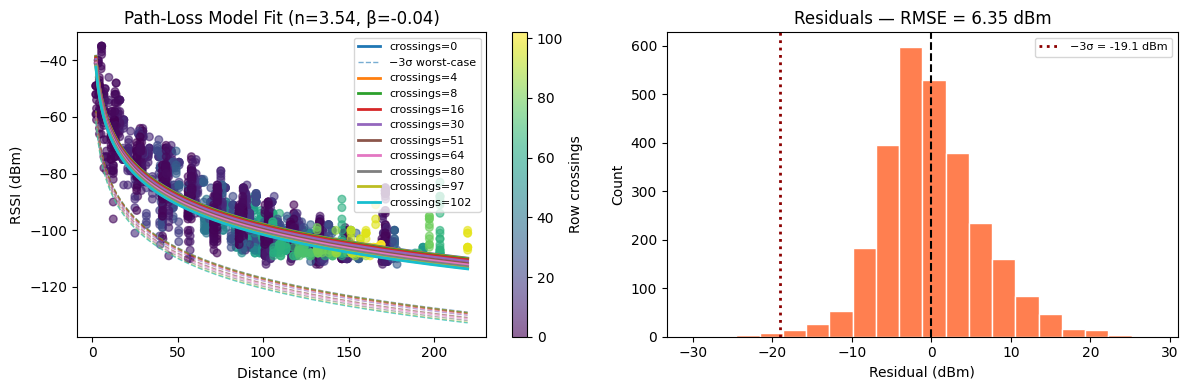

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Compute pl_pred / pl_residual (full model)
valid['pl_pred'] = X_pl_full @ coeffs_full
valid['pl_residual'] = valid['rssi'] - valid['pl_pred']
residual_std = valid['pl_residual'].std()

d_range = np.linspace(valid['distance'].min(), valid['distance'].max(), 200)

# Scatter plot colored by the row_crossings
scatter = axes[0].scatter(
    valid['distance'], valid['rssi'],
    c=valid['row_crossings'], cmap='viridis', alpha=0.6, s=30
)
cbar = plt.colorbar(scatter, ax=axes[0])
cbar.set_label('Row crossings')

#Draw the lines for just a FEW row crossings so the box doesn't get super crowded and messy
crossing_levels = sorted(valid['row_crossings'].unique())
if len(crossing_levels) > 8:
    step = len(crossing_levels) // 8
    crossing_levels = crossing_levels[::step]

for i, c in enumerate(crossing_levels):
    pl_line = A_g_full + n_log10_full * np.log10(d_range) + beta * c
    line, = axes[0].plot(d_range, pl_line, lw=2, label=f'crossings={c}')
    # 3-sigma worst-case envelope: where the mean physical-model line is
    # overly optimistic relative to the pessimistic tail we actually threshold against
    axes[0].plot(d_range, pl_line - 3 * residual_std, lw=1, linestyle='--',
                 color=line.get_color(), alpha=0.6,
                 label='−3σ worst-case' if i == 0 else None)

axes[0].set_xlabel('Distance (m)')
axes[0].set_ylabel('RSSI (dBm)')
axes[0].set_title(f'Path-Loss Model Fit (n={-n_log10_full/10:.2f}, β={beta:.2f})')
axes[0].legend(fontsize=8)

axes[1].hist(valid['pl_residual'], bins=20, color='coral', edgecolor='white')
axes[1].axvline(0, color='k', linestyle='--')
axes[1].axvline(-3 * residual_std, color='darkred', linestyle=':', lw=2,
                label=f'−3σ = {-3*residual_std:.1f} dBm')
axes[1].set_xlabel('Residual (dBm)')
axes[1].set_ylabel('Count')
axes[1].set_title(f'Residuals — RMSE = {rmse_full:.2f} dBm')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('pathloss_fit.png', dpi=150, bbox_inches='tight')
plt.show()

Moran's I.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from libpysal.weights import KNN
from esda.moran import Moran

# Aggregate to one mean residual per grid cell before testing.
cell_medians = (
    valid.groupby('grid_label')
    .agg(
        median_residual=('pl_residual', 'median'),
        x_m=('x_m', 'first'),
        y_m=('y_m', 'first'),
        n=('pl_residual', 'count')
    )
    .reset_index()
)

print(f"Running Moran's I on {len(cell_medians)} grid cell medians (not {len(valid)} individual packets)")

coords_arr = cell_medians[['x_m', 'y_m']].values
residuals_arr = cell_medians['median_residual'].values

# k-NN spatial weights are each cell's neighbors are its k nearest cells
k = min(5, len(cell_medians) - 1)

w = KNN.from_array(coords_arr, k=k)
w.transform = 'r'   # row standardize weights

np.random.seed(42)
moran = Moran(residuals_arr, w, permutations=999)

print("Moran's I Test ")
print(f"  Moran's I : {moran.I:.4f}")
print(f"  p-value   : {moran.p_sim:.4f}  (permutation, 999 iterations)")
print()

if moran.p_sim < 0.05 and moran.I > 0:
    print('Significant positive spatial autocorrelation: proceed to GPR residual model.')
    USE_GPR = True
else:
    print('No significant spatial autocorrelation: the path-loss model is sufficient.')
    USE_GPR = False

# Visualization of the data
plt.figure(figsize=(7, 3))
plt.hist(moran.sim, bins=40, color='lightgrey', edgecolor='white')
plt.axvline(moran.I, color='red', lw=2, label=f'Observed I = {moran.I:.3f}')
plt.xlabel("Moran's I")
plt.ylabel('Count')
plt.title(f"Moran's I Permutation Test (p = {moran.p_sim:.3f})")
plt.legend()
plt.tight_layout()
plt.savefig('morans_i.png', dpi=150, bbox_inches='tight')
plt.show()

2. GPR

2.1 Set-up

In [ ]:
# This is the Input + Target
X_gpr = valid[['x_m', 'y_m']].values.copy()
y_gpr = valid['pl_residual'].values.copy()

print(f'GPR input set: {X_gpr.shape[0]} packets, {X_gpr.shape[1]} input dims (x_m, y_m)')
print(f'Residual range : {y_gpr.min():.2f} to {y_gpr.max():.2f} dBm')
print(f'Residual mean  : {y_gpr.mean():.2f} dBm')

# Add tiny jitter to duplicate/near-duplicate coordinates so the kernel
# matrix K stays invertible (here multiple packets are logged at the same grid cell)
np.random.seed(42)
X_gpr += np.random.normal(0, 0.01, X_gpr.shape)

# To see how many exact coordinate duplicates existed before jitter
n_unique_coords = len(valid[['x_m', 'y_m']].drop_duplicates())
print(f'\nUnique (x_m, y_m) pairs: {n_unique_coords} / {len(valid)} packets')
print(f'Unique grid cells (grid_label): {valid["grid_label"].nunique()}')

2.2 scale

In [ ]:
# Scale coordinates to zero mean,
# GPR is sensitive to the scale of inputs (w/ it hyperparameter optimisation might fail/converge poorly)
scaler = StandardScaler()
X_gpr_scaled = scaler.fit_transform(X_gpr)

print('Coordinate scaling:')
print(f'  X mean: {scaler.mean_[0]:.2f} m  std: {scaler.scale_[0]:.2f} m')
print(f'  Y mean: {scaler.mean_[1]:.2f} m  std: {scaler.scale_[1]:.2f} m')

joblib.dump(scaler, f'{MODEL_DIR}/coord_scaler_full_dataset.pkl')
print('Saved: coord_scaler_full_dataset.pkl')

In [ ]:
x_scaled_range = X_gpr_scaled[:, 0].max() - X_gpr_scaled[:, 0].min()
y_scaled_range = X_gpr_scaled[:, 1].max() - X_gpr_scaled[:, 1].min()
length_scale_bounds = [(0.01, x_scaled_range), (0.01, y_scaled_range)]
print(f'length_scale_bounds: {length_scale_bounds}')

In [ ]:
# Baseline GPR (global WhiteKernel, nu=0.5) (nu was determined earlier through grid search)
kernel_final = (
    ConstantKernel(1.0, (0.1, 10.0)) *
    Matern(length_scale=[1.0, 1.0], length_scale_bounds=length_scale_bounds, nu=0.5) +
    WhiteKernel(noise_level=1.0, noise_level_bounds=(1e-3, 10.0))
)
gpr = GaussianProcessRegressor(
    kernel=kernel_final,
    n_restarts_optimizer=10,
    normalize_y=True,
    random_state=42
)
gpr.fit(X_gpr_scaled, y_gpr)
print('Baseline gpr fitted.')

joblib.dump(gpr, f'{MODEL_DIR}/gpr_model_full_dataset.pkl')
print('Saved: gpr_model_full_dataset.pkl')

2.3 Kernel with heteroscedastic noise

In [ ]:
# Estimate noise variance of each cell
cell_noise_var = valid.groupby('grid_label')['pl_residual'].var()
cell_counts = valid.groupby('grid_label')['pl_residual'].count()

min_reliable_n = 3
reliable_cells = cell_counts[cell_counts >= min_reliable_n].index
n_reliable = len(reliable_cells)
n_total_cells = valid['grid_label'].nunique()

print(f'Cells with >= {min_reliable_n} packets: {n_reliable} / {n_total_cells}')

global_median_var = cell_noise_var[reliable_cells].median()
print(f'Global median cell variance (fallback): {global_median_var:.3f} dB²')

valid['cell_noise_var'] = valid['grid_label'].map(cell_noise_var)
valid.loc[~valid['grid_label'].isin(reliable_cells), 'cell_noise_var'] = global_median_var
valid['cell_noise_var'] = valid['cell_noise_var'].fillna(global_median_var)

print(f'Per-point noise variance range: {valid["cell_noise_var"].min():.3f} to {valid["cell_noise_var"].max():.3f} dB²')

# Convert to standardized alpha
alpha_per_point = valid['cell_noise_var'].values / y_gpr.var()

#Fit heteroscedastic model: no WhiteKernel, alpha carries all the noise
kernel_hetero = (
    ConstantKernel(1.0, (0.1, 10.0)) *
    Matern(length_scale=[1.0, 1.0], length_scale_bounds=length_scale_bounds, nu=0.5)
)

gpr_hetero = GaussianProcessRegressor(
    kernel=kernel_hetero,
    alpha=alpha_per_point,
    n_restarts_optimizer=10,
    normalize_y=True,
    random_state=42
)
gpr_hetero.fit(X_gpr_scaled, y_gpr)

lml_hetero = gpr_hetero.log_marginal_likelihood(gpr_hetero.kernel_.theta)
lml_baseline = gpr.log_marginal_likelihood(gpr.kernel_.theta)

print(f'\n=== Quick LML Comparison ===')
print(f'Baseline (global WhiteKernel) LML : {lml_baseline:.2f}')
print(f'Heteroscedastic (per-cell alpha) LML: {lml_hetero:.2f}')
print(f'\nFitted kernel: {gpr_hetero.kernel_}')

UNCOMMENT FOR SANITY CHECK FOR NU!!!!!!

In [ ]:
"""
kernel_check = (
    ConstantKernel(1.0, (0.1, 10.0)) *
    Matern(length_scale=[1.0, 1.0], length_scale_bounds=length_scale_bounds, nu=1.5) +
    WhiteKernel(noise_level=1.0, noise_level_bounds=(1e-3, 10.0))
)
gp_check = GaussianProcessRegressor(kernel=kernel_check, n_restarts_optimizer=10,
                                      normalize_y=True, random_state=42)
gp_check.fit(X_gpr_scaled, y_gpr)
lml_check = gp_check.log_marginal_likelihood(gp_check.kernel_.theta)

lml_05 = gpr.log_marginal_likelihood(gpr.kernel_.theta)
print(f'nu=0.5 LML: {lml_05:.2f}')
print(f'nu=1.5 LML: {lml_check:.2f}')
print('nu=0.5 still preferred' if lml_05 > lml_check else 'WARNING: nu=1.5 now preferred — reconsider')
"""

In [ ]:
# Save the model
joblib.dump(gpr_hetero, f'{MODEL_DIR}/gpr_hetero_final_candidate.pkl')
joblib.dump(alpha_per_point, f'{MODEL_DIR}/alpha_hetero_final.pkl')
print('Saved: gpr_hetero_final_candidate.pkl, alpha_hetero_final.pkl')

2.4 Grouped k-fold cross validation

In [ ]:
groups = valid['grid_label'].values
gkf = GroupKFold(n_splits=5)

cv_pred_residual_hetero = np.full(len(y_gpr), np.nan)
cv_pred_std_hetero = np.full(len(y_gpr), np.nan)
fold_rmse_hetero = []

for train_idx, test_idx in gkf.split(X_gpr_scaled, y_gpr, groups=groups):
    gp_cv = GaussianProcessRegressor(
        kernel=kernel_hetero,
        alpha=alpha_per_point[train_idx],
        n_restarts_optimizer=10,
        normalize_y=True,
        random_state=42
    )
    gp_cv.fit(X_gpr_scaled[train_idx], y_gpr[train_idx])

    fold_pred, fold_std = gp_cv.predict(X_gpr_scaled[test_idx], return_std=True)
    cv_pred_residual_hetero[test_idx] = fold_pred
    cv_pred_std_hetero[test_idx] = fold_std

    fold_rmse_hetero.append(np.sqrt(mean_squared_error(y_gpr[test_idx], fold_pred)))
    print(f'  Fold complete: RMSE = {fold_rmse_hetero[-1]:.3f} dBm')

assert not np.isnan(cv_pred_residual_hetero).any(), "Some points were never in a test fold!"
assert not np.isnan(cv_pred_std_hetero).any(), "Some points never got a std estimate!"

cv_rmse_mean = np.mean(fold_rmse_hetero)
cv_rmse_std = np.std(fold_rmse_hetero)

print(f'\nHeteroscedastic CV RMSE: {cv_rmse_mean:.3f} ± {cv_rmse_std:.3f} dBm')

joblib.dump(fold_rmse_hetero, f'{MODEL_DIR}/cv_fold_rmse_hetero.pkl')
joblib.dump(cv_pred_residual_hetero, f'{MODEL_DIR}/cv_pred_residual_hetero.pkl')
joblib.dump(cv_pred_std_hetero, f'{MODEL_DIR}/cv_pred_std_hetero.pkl')
print('Saved: cv_fold_rmse_hetero.pkl, cv_pred_residual_hetero.pkl, cv_pred_std_hetero.pkl')


3. SNR - Path-Loss Model

In [7]:
snr = valid['snr'].values

X_pl_snr = np.column_stack([np.ones(len(valid)), log_d, crossings])
coeffs_snr, _, _, _ = lstsq(X_pl_snr, snr, rcond=None)
A_g_snr, n_log10_snr, beta_snr = coeffs_snr
pred_snr = X_pl_snr @ coeffs_snr
rmse_snr = np.sqrt(mean_squared_error(snr, pred_snr))

valid['snr_pred'] = pred_snr
valid['snr_residual'] = valid['snr'] - valid['snr_pred']

print('=== SNR Path-Loss Model ===')
print(f'  A_g (intercept)     : {A_g_snr:.2f} dB')
print(f'  n   (path-loss exp) : {-n_log10_snr/10:.3f}')
print(f'  β   (row penalty)   : {beta_snr:.3f} dB per row crossed')
print(f'  RMSE                : {rmse_snr:.2f} dB')


joblib.dump(coeffs_snr, f'{MODEL_DIR}/pathloss_coeffs_snr_full_dataset.pkl')
joblib.dump(
    {'A_g_snr': A_g_snr, 'n_snr': -n_log10_snr/10, 'beta_snr': beta_snr, 'rmse_snr': rmse_snr},
    f'{MODEL_DIR}/pathloss_summary_snr_full_dataset.pkl'
)

=== SNR Path-Loss Model ===
  A_g (intercept)     : 26.18 dB
  n   (path-loss exp) : 1.018
  β   (row penalty)   : -0.100 dB per row crossed
  RMSE                : 5.36 dB


['./pathloss_summary_snr_full_dataset.pkl']

In [8]:
snr_coef_table, snr_fit_stats = ols_significance_stats(
    X_pl_snr, snr, coeffs_snr, ['intercept', 'log10_distance_m', 'row_crossings']
)

print('=== SNR Path-Loss Model — Statistical Significance ===')
print(f"n={snr_fit_stats['n']}, R²={snr_fit_stats['r2']:.3f}, adj. R²={snr_fit_stats['adj_r2']:.3f}")
print(f"Whole-model F-test: F={snr_fit_stats['f_stat']:.1f}, p={snr_fit_stats['f_p_value']:.2e}")
print(snr_coef_table.round(5).to_string(index=False))

joblib.dump({**snr_fit_stats, 'coefficients': snr_coef_table},
            f'{MODEL_DIR}/pathloss_significance_snr_full_dataset.pkl')
print('Saved: pathloss_significance_snr_full_dataset.pkl')

=== SNR Path-Loss Model — Statistical Significance ===
n=2748, R²=0.473, adj. R²=0.472
Whole-model F-test: F=1230.6, p=0.00e+00
            term  coefficient  std_error    t_stat  p_value
       intercept     26.17846    0.58548  44.71305      0.0
log10_distance_m    -10.18096    0.32306 -31.51417      0.0
   row_crossings     -0.10043    0.00440 -22.85008      0.0
Saved: pathloss_significance_snr_full_dataset.pkl


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

d_range = np.linspace(valid['distance'].min(), valid['distance'].max(), 200)

scatter = axes[0].scatter(
    valid['distance'], valid['snr'],
    c=valid['row_crossings'], cmap='viridis', alpha=0.6, s=30
)
cbar = plt.colorbar(scatter, ax=axes[0])
cbar.set_label('Row crossings')

crossing_levels = sorted(valid['row_crossings'].unique())
if len(crossing_levels) > 8:
    step = len(crossing_levels) // 8
    crossing_levels = crossing_levels[::step]

for c in crossing_levels:
    pl_line = A_g_snr + n_log10_snr * np.log10(d_range) + beta_snr * c
    axes[0].plot(d_range, pl_line, lw=2, label=f'crossings={c}')

axes[0].set_xlabel('Distance (m)')
axes[0].set_ylabel('SNR (dB)')
axes[0].set_title(f'SNR Path-Loss Model Fit (n={-n_log10_snr/10:.2f}, β={beta_snr:.2f})')
axes[0].legend(fontsize=8)

axes[1].hist(valid['snr_residual'], bins=20, color='coral', edgecolor='white')
axes[1].axvline(0, color='k', linestyle='--')
axes[1].set_xlabel('Residual (dB)')
axes[1].set_ylabel('Count')
axes[1].set_title(f'SNR Residuals — RMSE = {rmse_snr:.2f} dB')

plt.tight_layout()
plt.savefig('pathloss_fit_snr.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
cell_medians_snr = (
    valid.groupby('grid_label')
    .agg(
        median_residual=('snr_residual', 'median'),
        x_m=('x_m', 'first'),
        y_m=('y_m', 'first'),
        n=('snr_residual', 'count')
    )
    .reset_index()
)

print(f"Running Moran's I on {len(cell_medians_snr)} grid cell medians (SNR residuals)")

coords_arr_snr = cell_medians_snr[['x_m', 'y_m']].values
residuals_arr_snr = cell_medians_snr['median_residual'].values

k_snr = min(5, len(cell_medians_snr) - 1)
w_snr = KNN.from_array(coords_arr_snr, k=k_snr)
w_snr.transform = 'r'

np.random.seed(42)
moran_snr = Moran(residuals_arr_snr, w_snr, permutations=999)

print("=== Moran's I Test — SNR residuals ===")
print(f"  Moran's I : {moran_snr.I:.4f}")
print(f"  p-value   : {moran_snr.p_sim:.4f}  (permutation, 999 iterations)")
print()

if moran_snr.p_sim < 0.05 and moran_snr.I > 0:
    print('Significant positive spatial autocorrelation: proceed to GPR residual model for SNR.')
else:
    print('No significant spatial autocorrelation in SNR residuals: GPR step may add little here.')

plt.figure(figsize=(7, 3))
plt.hist(moran_snr.sim, bins=40, color='lightgrey', edgecolor='white')
plt.axvline(moran_snr.I, color='red', lw=2, label=f'Observed I = {moran_snr.I:.3f}')
plt.xlabel("Moran's I")
plt.ylabel('Count')
plt.title(f"Moran's I Permutation Test — SNR (p = {moran_snr.p_sim:.3f})")
plt.legend()
plt.tight_layout()
plt.savefig('morans_i_snr.png', dpi=150, bbox_inches='tight')
plt.show()

3.1 GPR — SNR (heteroscedastic)

Reuses the same coordinates (`X_gpr_scaled`), grid (`grid_df`, `xx`, `yy`), and CV folds (`groups`, `gkf`) as the RSSI GPR step, only the target changes to `snr_residual`. Everything is kept in separate `*_snr`-suffixed variables so nothing here overwrites the RSSI model or its results.

In [ ]:
y_gpr_snr = valid['snr_residual'].values.copy()

print(f'GPR target (SNR): {len(y_gpr_snr)} packets')
print(f'Residual range : {y_gpr_snr.min():.2f} to {y_gpr_snr.max():.2f} dB')
print(f'Residual mean  : {y_gpr_snr.mean():.2f} dB')

# Reuses X_gpr_scaled / scaler from the RSSI GPR step above

In [ ]:
cell_noise_var_snr = valid.groupby('grid_label')['snr_residual'].var()
cell_counts_snr = valid.groupby('grid_label')['snr_residual'].count()

reliable_cells_snr = cell_counts_snr[cell_counts_snr >= min_reliable_n].index
global_median_var_snr = cell_noise_var_snr[reliable_cells_snr].median()
print(f'Global median cell variance (fallback, SNR): {global_median_var_snr:.3f} dB²')

valid['cell_noise_var_snr'] = valid['grid_label'].map(cell_noise_var_snr)
valid.loc[~valid['grid_label'].isin(reliable_cells_snr), 'cell_noise_var_snr'] = global_median_var_snr
valid['cell_noise_var_snr'] = valid['cell_noise_var_snr'].fillna(global_median_var_snr)

# Convert to standardized alpha
alpha_per_point_snr = valid['cell_noise_var_snr'].values / y_gpr_snr.var()

kernel_hetero_snr = (
    ConstantKernel(1.0, (0.1, 10.0)) *
    Matern(length_scale=[1.0, 1.0], length_scale_bounds=length_scale_bounds, nu=0.5)
)

gpr_hetero_snr = GaussianProcessRegressor(
    kernel=kernel_hetero_snr,
    alpha=alpha_per_point_snr,
    n_restarts_optimizer=10,
    normalize_y=True,
    random_state=42
)
gpr_hetero_snr.fit(X_gpr_scaled, y_gpr_snr)

print(f'\nFitted SNR kernel: {gpr_hetero_snr.kernel_}')

In [ ]:
# Save the model
joblib.dump(gpr_hetero_snr, f'{MODEL_DIR}/gpr_hetero_snr_final_candidate.pkl')
joblib.dump(alpha_per_point_snr, f'{MODEL_DIR}/alpha_hetero_snr_final.pkl')
print('Saved: gpr_hetero_snr_final_candidate.pkl, alpha_hetero_snr_final.pkl')

3.2 Grouped k-fold cross validation — SNR

In [ ]:
cv_pred_residual_hetero_snr = np.full(len(y_gpr_snr), np.nan)
cv_pred_std_hetero_snr = np.full(len(y_gpr_snr), np.nan)
fold_rmse_hetero_snr = []

for train_idx, test_idx in gkf.split(X_gpr_scaled, y_gpr_snr, groups=groups):
    gp_cv_snr = GaussianProcessRegressor(
        kernel=kernel_hetero_snr,
        alpha=alpha_per_point_snr[train_idx],
        n_restarts_optimizer=10,
        normalize_y=True,
        random_state=42
    )
    gp_cv_snr.fit(X_gpr_scaled[train_idx], y_gpr_snr[train_idx])

    fold_pred_snr, fold_std_snr = gp_cv_snr.predict(X_gpr_scaled[test_idx], return_std=True)
    cv_pred_residual_hetero_snr[test_idx] = fold_pred_snr
    cv_pred_std_hetero_snr[test_idx] = fold_std_snr

    fold_rmse_hetero_snr.append(np.sqrt(mean_squared_error(y_gpr_snr[test_idx], fold_pred_snr)))
    print(f'  Fold complete: RMSE = {fold_rmse_hetero_snr[-1]:.3f} dB')

assert not np.isnan(cv_pred_residual_hetero_snr).any(), "Some points were never in a test fold!"
assert not np.isnan(cv_pred_std_hetero_snr).any(), "Some points never got a std estimate!"

cv_rmse_mean_snr = np.mean(fold_rmse_hetero_snr)
cv_rmse_std_snr = np.std(fold_rmse_hetero_snr)

print(f'\nSNR heteroscedastic CV RMSE: {cv_rmse_mean_snr:.3f} ± {cv_rmse_std_snr:.3f} dB')
print(f'SNR path-loss-only RMSE    : {rmse_snr:.3f} dB (baseline, no GPR)')

joblib.dump(fold_rmse_hetero_snr, f'{MODEL_DIR}/cv_fold_rmse_hetero_snr.pkl')
joblib.dump(cv_pred_residual_hetero_snr, f'{MODEL_DIR}/cv_pred_residual_hetero_snr.pkl')
joblib.dump(cv_pred_std_hetero_snr, f'{MODEL_DIR}/cv_pred_std_hetero_snr.pkl')
print('Saved: cv_fold_rmse_hetero_snr.pkl, cv_pred_residual_hetero_snr.pkl, cv_pred_std_hetero_snr.pkl')